In [4]:
import numpy as np

observations = 1000
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))
inputs = np.column_stack((xs, zs))

noise = np.random.uniform(low=-1, high=1, size=(observations, 1))
targets = 2*xs - 3*zs + 5 + noise

np.savez('TF_dataset', inputs=inputs, targets=targets)
print("Plik TF_dataset.npz został pomyślnie wygenerowany i zapisany w pamięci sesji!")

Plik TF_dataset.npz został pomyślnie wygenerowany i zapisany w pamięci sesji!


Optimizer  | Funkcja Straty       | Waga xs   | Waga zs   | Bias     
--------------------------------------------------------------------
ADAM       | MEAN_SQUARED_ERROR   | 1.6775  | -1.6572  | 2.1551
ADAM       | MEAN_ABSOLUTE_ERROR  | 2.0127  | -2.9329  | 3.6821
RMSPROP    | MEAN_SQUARED_ERROR   | 1.9451  | -1.8316  | 2.4172
RMSPROP    | MEAN_ABSOLUTE_ERROR  | 2.0199  | -2.5162  | 2.2784
SGD        | MEAN_SQUARED_ERROR   | 2.0216  | -2.9824  | 5.0113
SGD        | MEAN_ABSOLUTE_ERROR  | 1.9926  | -2.9692  | 5.0219
Trwa trenowanie sieci nieliniowej 
Trening zakończony


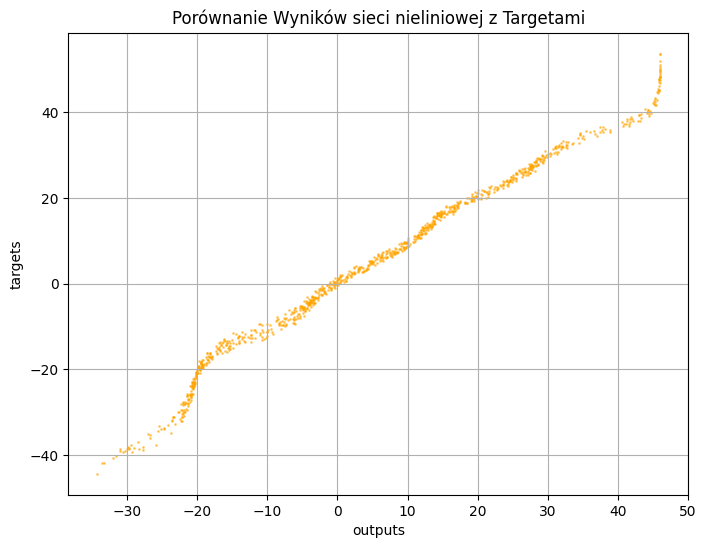

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

training_data = np.load('TF_dataset.npz')
output_size = 1


optimizers_to_test = ['adam', 'rmsprop', 'sgd']
losses_to_test = ['mean_squared_error', 'mean_absolute_error']

# Nagłówek mini-tabeli wyników
print(f"{'Optimizer':<10} | {'Funkcja Straty':<20} | {'Waga xs':<9} | {'Waga zs':<9} | {'Bias':<9}")
print("-" * 68)

for opt in optimizers_to_test:
    for loss_fn in losses_to_test:
        model_linear = tf.keras.Sequential([
            tf.keras.layers.Dense(output_size)
        ])

        model_linear.compile(optimizer=opt, loss=loss_fn)
        model_linear.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=0)

        w, b = model_linear.layers[0].get_weights()
        print(f"{opt.upper():<10} | {loss_fn.upper():<20} | {w[0][0]:.4f}  | {w[1][0]:.4f}  | {b[0]:.4f}")

model_nonlinear = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="sigmoid"),
    tf.keras.layers.Dense(5, activation="sigmoid"),
    tf.keras.layers.Dense(output_size)
])

model_nonlinear.compile(optimizer='sgd', loss='mean_squared_error')

print("Trwa trenowanie sieci nieliniowej ")
model_nonlinear.fit(training_data['inputs'], training_data['targets'], epochs=150, verbose=0)
print("Trening zakończony")

# Generowanie predykcji do wykresu
outputs = np.squeeze(model_nonlinear.predict_on_batch(training_data['inputs']))
targets = np.squeeze(training_data['targets'])

# Wizualizacja efektu nieliniowości
plt.figure(figsize=(8, 6))
plt.scatter(outputs, targets, color='orange', alpha=0.5, s=1)
plt.title('Porównanie Wyników sieci nieliniowej z Targetami')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.grid(True)
plt.show()
